In [1]:
import pulp
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
model = pulp.LpProblem(
    "Factory_Profit_Maximization",
    pulp.LpMaximize
)

In [3]:
chairs = pulp.LpVariable(
    "Chairs",
    lowBound=0,
    cat='Integer'
)

tables = pulp.LpVariable(
    "Tables",
    lowBound=0,
    cat='Integer'
)

In [4]:
model += 50 * chairs + 80 * tables

In [5]:
model += 5 * chairs + 8 * tables <= 400

model += 10 * chairs + 15 * tables <= 800

In [10]:
solver = pulp.COIN_CMD(path="/opt/homebrew/bin/cbc")

model.solve(solver)

print("Optimization Status:", pulp.LpStatus[model.status])

print("Optimal Chairs Production:", chairs.varValue)

print("Optimal Tables Production:", tables.varValue)

print("Maximum Profit:", pulp.value(model.objective))

Welcome to the CBC MILP Solver 
Version: 2.10.13 
Build Date: Mar 11 2026 

command line - /opt/homebrew/bin/cbc /var/folders/nv/40bx0_zn29934_vxnx0fmyl40000gn/T/13bc08bdbdc14c10bd8212926edc5e28-pulp.mps -max -timeMode elapsed -branch -printingOptions all -solution /var/folders/nv/40bx0_zn29934_vxnx0fmyl40000gn/T/13bc08bdbdc14c10bd8212926edc5e28-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 7 COLUMNS
At line 18 RHS
At line 21 BOUNDS
At line 24 ENDATA
Problem MODEL has 2 rows, 2 columns and 4 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Continuous objective value is 4000 - 0.00 seconds
Cgl0004I processed model has 2 rows, 2 columns (2 integer (0 of which binary)) and 4 elements
Cutoff increment increased from 1e-05 to 9.9999
Cbc0012I Integer solution of 4000 found by DiveCoefficient after 0 iterations and 0 nodes (0.00 seconds)
Cbc0001I Search completed - best objective 4000, took 0 iterations and 0 node

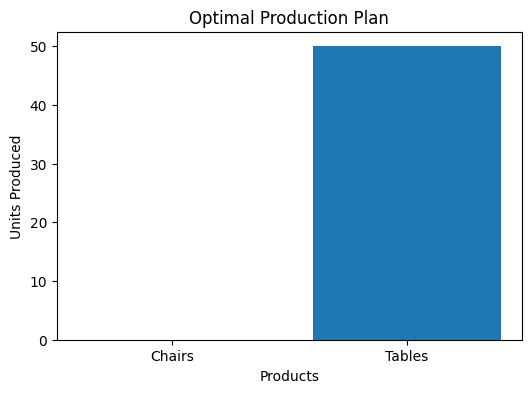

In [11]:
products = ["Chairs", "Tables"]

values = [chairs.varValue, tables.varValue]

plt.figure(figsize=(6, 4))

plt.bar(products, values)

plt.title("Optimal Production Plan")

plt.xlabel("Products")

plt.ylabel("Units Produced")

plt.show()

# Business Insights

- The optimization model successfully maximized factory profit.
- Resource constraints limited total production capacity.
- The model identified the most profitable production strategy.
- Linear Programming helped optimize business decision-making efficiently.
- The solution demonstrates how optimization can improve operational planning.

# Constraints Used

## Labor Constraint
The factory has limited labor hours available for production.

## Material Constraint
The factory has limited raw materials for manufacturing products.

These constraints ensure realistic business optimization.